In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import logging

# 로깅 설정
logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")


In [2]:
def load_params(root, simcode):
    """
    Load CAMELS parameter file.

    Parameters
    ----------
    root : str
        Root directory where CAMELS data is stored.
    simcode : str
        Simulation code ("IllustrisTNG" or "SIMBA").

    Returns
    -------
    dict
        Dictionary containing arrays of Omega_m, sigma_8, SN1, AGN1, SN2, AGN2.
    """
    param_file = os.path.join(root, f"params_LH_{simcode}.txt")
    Omega_m, sigma_8, SN1, AGN1, SN2, AGN2 = np.loadtxt(param_file, unpack=True)
    return {
        "Omega_m": Omega_m,
        "sigma_8": sigma_8,
        "SN1": SN1,
        "AGN1": AGN1,
        "SN2": SN2,
        "AGN2": AGN2,
    }

def load_maps(root, field, simcode, z_tag="z=0.00"):
    """
    Load CAMELS map data file.

    Parameters
    ----------
    root : str
        Root directory where CAMELS data is stored.
    field : str
        Field type ("Mtot" or "P").
    simcode : str
        Simulation code ("IllustrisTNG" or "SIMBA").
    z_tag : str
        Redshift tag in filename.

    Returns
    -------
    np.ndarray
        Array of shape (1000, 15, 256, 256).
    """
    maps_file = os.path.join(root, f"Maps_{field}_{simcode}_LH_{z_tag}.npy")
    arr = np.load(maps_file)
    arr = arr.reshape(1000, 15, 256, 256)
    logging.info(f"Loaded {maps_file} with shape {arr.shape}")
    return arr

# 데이터 경로
ROOT = "./data/CAMELS_multifield"

# SIMBA 데이터 불러오기
params_simba = load_params(ROOT, "SIMBA")
maps_simba_mtot = load_maps(ROOT, "Mtot", "SIMBA")
maps_simba_p = load_maps(ROOT, "P", "SIMBA")

2025-08-19 13:58:45,804 [INFO] Loaded ./data/CAMELS_multifield/Maps_Mtot_SIMBA_LH_z=0.00.npy with shape (1000, 15, 256, 256)
2025-08-19 13:58:58,203 [INFO] Loaded ./data/CAMELS_multifield/Maps_P_SIMBA_LH_z=0.00.npy with shape (1000, 15, 256, 256)


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary  # pip install torchinfo 필요

# 250818_a3net/unet/model.py 안의 클래스 불러오기
from unet.model import UNetEncoderRegressor  

# -----------------------------
# 1. Initialize U-Net Model
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNetEncoderRegressor().to(device)

print("Model initialized on:", device)

# -----------------------------
# 2. Display Model Summary
# -----------------------------
# 입력 shape: (batch_size, 15, 256, 256)
summary(model, input_size=(2, 15, 256, 256))  # batch_size=2 예시


Model initialized on: cuda


Layer (type:depth-idx)                   Output Shape              Param #
UNetEncoderRegressor                     [2, 6]                    --
├─ConvBlockEnc2D: 1-1                    [2, 32, 128, 128]         --
│    └─ReplicationPad2d: 2-1             [2, 15, 260, 260]         --
│    └─Conv2d: 2-2                       [2, 32, 128, 128]         12,032
│    └─BatchNorm2d: 2-3                  [2, 32, 128, 128]         64
│    └─ReLU: 2-4                         [2, 32, 128, 128]         --
├─ConvBlockEnc2D: 1-2                    [2, 64, 64, 64]           --
│    └─ReplicationPad2d: 2-5             [2, 32, 132, 132]         --
│    └─Conv2d: 2-6                       [2, 64, 64, 64]           51,264
│    └─BatchNorm2d: 2-7                  [2, 64, 64, 64]           128
│    └─ReLU: 2-8                         [2, 64, 64, 64]           --
├─ConvBlockEnc2D: 1-3                    [2, 128, 32, 32]          --
│    └─ReplicationPad2d: 2-9             [2, 64, 68, 68]           --
│    └

In [4]:
print(model)

UNetEncoderRegressor(
  (enc1): ConvBlockEnc2D(
    (pad): ReplicationPad2d((2, 2, 2, 2))
    (conv): Conv2d(15, 32, kernel_size=(5, 5), stride=(2, 2))
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (enc2): ConvBlockEnc2D(
    (pad): ReplicationPad2d((2, 2, 2, 2))
    (conv): Conv2d(32, 64, kernel_size=(5, 5), stride=(2, 2))
    (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (enc3): ConvBlockEnc2D(
    (pad): ReplicationPad2d((2, 2, 2, 2))
    (conv): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2))
    (bn): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (enc4): ConvBlockEnc2D(
    (pad): ReplicationPad2d((2, 2, 2, 2))
    (conv): Conv2d(128, 256, kernel_size=(5, 5), stride=(2, 2))
    (bn): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
 

In [5]:
# -----------------------------
# 3. Test Loss Functions
# -----------------------------
# Define candidate loss functions
criterion_mse = nn.MSELoss()
#criterion_l1 = nn.L1Loss()

# Dummy batch (2 samples, 15 maps of 256x256)
x_dummy = torch.randn(2, 15, 256, 256).to(device)
y_dummy = torch.randn(2, 6).to(device)

# Forward pass
y_pred = model(x_dummy)

print("Pred shape:", y_pred.shape)  # (2,6)

# Test losses
loss_mse = criterion_mse(y_pred, y_dummy)
print("MSE Loss:", loss_mse.item())

Pred shape: torch.Size([2, 6])
MSE Loss: 1.7213354110717773


In [6]:
# -----------------------------
# 4. Set Optimizer & Scheduler
# -----------------------------
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("Optimizer and scheduler set.")


Optimizer and scheduler set.


In [7]:
# -----------------------------
# 5. Dummy Training Loop
# -----------------------------
epochs = 3
for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Forward
    y_pred = model(x_dummy)
    loss = criterion_mse(y_pred, y_dummy)

    # Backward
    loss.backward()
    optimizer.step()
    scheduler.step()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")

Epoch 1/3, Loss: 1.7213, LR: 0.001000
Epoch 2/3, Loss: 1.1451, LR: 0.001000
Epoch 3/3, Loss: 1.3705, LR: 0.001000


In [11]:
# -----------------------------
# 0. Device 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 1. Model / Criterion / Optimizer
# -----------------------------
model = UNetEncoderRegressor(in_channels=15, out_dim=2).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)

# -----------------------------
# 2. Dataset / Dataloader 준비
# -----------------------------
from unet.data_loader import CAMELSDataset
from torch.utils.data import DataLoader

# dict → ndarray 변환 (keys 순서에 맞춰 배열로 변환)
params_array = np.column_stack([params_simba[k] for k in sorted(params_simba.keys())])

dataset = CAMELSDataset(maps_simba_mtot, params_array)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

# -----------------------------
# 3. Training Loop
# -----------------------------
epochs = 3
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for x, y in dataloader:
        # GPU/CPU 맞추기
        x = x.to(device)
        y = y.to(device)

        # Forward
        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)

        # Backward
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)  # 배치별 loss 합산
    
    scheduler.step()
    epoch_loss = running_loss / len(dataset)   # 평균 loss
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, LR: {scheduler.get_last_lr()[0]:.6f}")


2025-08-19 14:02:58,193 [INFO] [data_loader] 🧠 Using in-memory maps: shape=(1000, 15, 256, 256), dtype=float32
2025-08-19 14:02:58,194 [INFO] [data_loader] 🧠 Using in-memory params: shape=(1000, 6), dtype=float64


Using device: cuda


2025-08-19 14:02:58,991 [INFO] [data_loader] ✅ Dataset ready | maps: shape=(1000, 15, 256, 256), dtype=float32, min=5198060544.000, max=3314766101610496.000 | params[2params]: shape=(1000, 2), dtype=float64


Epoch 1/3, Loss: 0.8653, LR: 0.001000
Epoch 2/3, Loss: 0.6401, LR: 0.001000
Epoch 3/3, Loss: 0.6280, LR: 0.001000


Epoch 1/30, Loss: 0.625719
Epoch 2/30, Loss: 0.624954
Epoch 3/30, Loss: 0.614600
Epoch 4/30, Loss: 0.607332
Epoch 5/30, Loss: 0.599420
Epoch 6/30, Loss: 0.594416
Epoch 7/30, Loss: 0.580055
Epoch 8/30, Loss: 0.563381
Epoch 9/30, Loss: 0.537183
Epoch 10/30, Loss: 0.538788
Epoch 11/30, Loss: 0.482730
Epoch 12/30, Loss: 0.443480
Epoch 13/30, Loss: 0.406648
Epoch 14/30, Loss: 0.372947
Epoch 15/30, Loss: 0.313788
Epoch 16/30, Loss: 0.263930
Epoch 17/30, Loss: 0.257926
Epoch 18/30, Loss: 0.208103
Epoch 19/30, Loss: 0.176646
Epoch 20/30, Loss: 0.140992
Epoch 21/30, Loss: 0.113621
Epoch 22/30, Loss: 0.107973
Epoch 23/30, Loss: 0.114060
Epoch 24/30, Loss: 0.096532
Epoch 25/30, Loss: 0.081332
Epoch 26/30, Loss: 0.080333
Epoch 27/30, Loss: 0.063350
Epoch 28/30, Loss: 0.061518
Epoch 29/30, Loss: 0.058259
Epoch 30/30, Loss: 0.059686


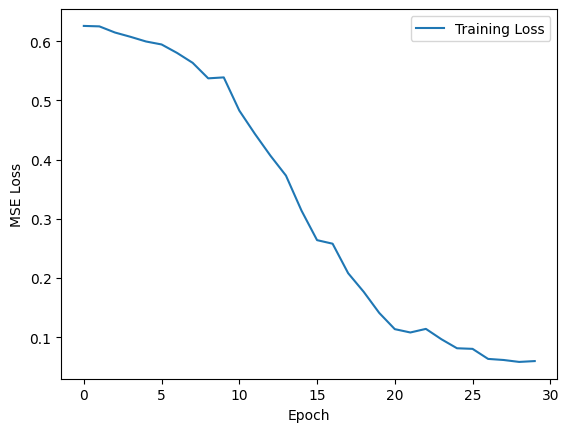

In [12]:
loss_history = []

epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    
    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()
        y_pred = model(x)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * x.size(0)
    
    scheduler.step()
    epoch_loss = running_loss / len(dataset)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.6f}")

# --- Loss curve 시각화
import matplotlib.pyplot as plt
plt.plot(loss_history, label="Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


In [ ]:
# 모델 평가 모드
model.eval()
with torch.no_grad():
    # 배치 하나 뽑기
    x, y_true = next(iter(dataloader))
    x = x.to(device)
    y_true = y_true.to(device)

    y_pred = model(x)

# CPU로 이동해서 numpy 변환
y_true = y_true.cpu().numpy()
y_pred = y_pred.cpu().numpy()

# 몇 개 샘플 출력
for i in range(5):
    print(f"Sample {i+1}")
    print("True :", y_true[i])
    print("Pred :", y_pred[i])
    print("-" * 30)


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# R2, MSE 계산
r2_omega = r2_score(y_true[:,0], y_pred[:,0])
r2_sigma = r2_score(y_true[:,1], y_pred[:,1])
mse_omega = mean_squared_error(y_true[:,0], y_pred[:,0])
mse_sigma = mean_squared_error(y_true[:,1], y_pred[:,1])

plt.figure(figsize=(7,6))

# 산점도
plt.scatter(y_true[:,0], y_pred[:,0], label=f"Omega_m (R²={r2_omega:.3f}, MSE={mse_omega:.3e})", alpha=0.7, color="tab:blue")
plt.scatter(y_true[:,1], y_pred[:,1], label=f"sigma_8 (R²={r2_sigma:.3f}, MSE={mse_sigma:.3e})", alpha=0.7, color="tab:orange")

# y=x 기준선
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         "k--", lw=2, label="Ideal")

# 라벨/제목
plt.xlabel("True Parameter Value", fontsize=12)
plt.ylabel("Predicted Parameter Value", fontsize=12)
plt.title("Prediction of Cosmological Parameters\nModel: UNetEncoderRegressor (SIMBA Mtot)", fontsize=14)

# 범례
plt.legend(fontsize=10, loc="upper left", frameon=True)

# Grid
plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# 1. Device 설정
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -----------------------------
# 2. Dataset / Dataloader 준비
# -----------------------------
dataset = CAMELSDataset(maps_simba_mtot, params_simba)  
dataloader = DataLoader(dataset, batch_size=16, shuffle=True, num_workers=2)

# -----------------------------
# 3. 모델, Loss, Optimizer
# -----------------------------
model = UNetEncoderRegressor(in_channels=15, out_dim=2).to(device)  
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# -----------------------------
# 4. Training Loop
# -----------------------------
num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    
    for imgs, targets in dataloader:
        imgs, targets = imgs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
    
    epoch_loss = running_loss / len(dataloader.dataset)
    train_losses.append(epoch_loss)
    
    print(f"Epoch [{epoch+1}/{num_epochs}] Loss: {epoch_loss:.6f}")

# -----------------------------
# 5. 학습 결과 시각화
# -----------------------------
plt.plot(train_losses, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

# -----------------------------
# 6. 예측 vs 실제 비교 (샘플 몇 개)
# -----------------------------
model.eval()
with torch.no_grad():
    imgs, targets = next(iter(dataloader))
    imgs, targets = imgs.to(device), targets.to(device)
    preds = model(imgs)
    
    preds = preds.cpu().numpy()
    targets = targets.cpu().numpy()

print("Targets (first 5):", targets[:5])
print("Predictions (first 5):", preds[:5])


In [ ]:
import matplotlib.pyplot as plt

def plot_scatter(y_true, y_pred, param_names=["Omega_m", "sigma_8"]):
    """
    산점도 플롯: 실제값 vs 예측값
    """
    num_params = y_true.shape[1]
    fig, axes = plt.subplots(1, num_params, figsize=(6*num_params, 5))

    if num_params == 1:
        axes = [axes]  # 파라미터가 하나인 경우 리스트로 처리
    
    for i in range(num_params):
        ax = axes[i]
        ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.5, s=5, label="Predictions")
        ax.plot([y_true[:, i].min(), y_true[:, i].max()],
                [y_true[:, i].min(), y_true[:, i].max()],
                'r--', label="Ideal")
        ax.set_xlabel(f"True {param_names[i]}")
        ax.set_ylabel(f"Predicted {param_names[i]}")
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()


In [ ]:
# 모델 평가 모드
model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for x_batch, y_batch in dataloader:
        # --- 여기서 GPU/CPU 맞춰주기 ---
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model(x_batch)

        all_preds.append(preds.cpu().numpy())   # numpy 변환은 CPU에서
        all_targets.append(y_batch.cpu().numpy())

import numpy as np
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# 산점도 그리기
plot_scatter(all_targets, all_preds, param_names=["Omega_m", "sigma_8"])


In [ ]:
import torch
import matplotlib.pyplot as plt

# 증강 함수
aug = RandomFlipRotate2D(p_flip=0.5, generator=torch.Generator().manual_seed(0))

# 샘플 데이터 (여기선 랜덤 1채널 이미지)
x = torch.arange(64*64).reshape(64,64).float()  # deterministic test image

# 여러 번 증강해서 결과 저장
n_trials = 200
results = []
hashes = set()

for i in range(n_trials):
    x_aug = aug(x.clone())
    # 간단히 hash (픽셀 값 tensor → string 변환 후 해시)
    h = hash(x_aug.numpy().tobytes())
    hashes.add(h)
    results.append(x_aug)

print(f"실험 반복 횟수: {n_trials}")
print(f"발견된 unique transform 개수: {len(hashes)}")

# 몇 개 결과 시각화
fig, axes = plt.subplots(2, 4, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(results[i].numpy(), cmap="viridis")
    ax.set_title(f"Aug {i}")
    ax.axis("off")
plt.show()
